# Djokovic Tennis Matches Analysis - EDA

$\textbf{Data}$: This dataset contains information on $1278$ matches of Novak Djokovic's career. It contains $17$ variables columns that will be used to predict the odds of a match, and the winner. This dataset has been obtained from the atp_tennis.csv dataset by extracting only Djokovic's matches.

### 1. Import Libraries

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas.api.types as ptypes # for data type querying

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams.update({
    "font.size": 14,     
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"


### 2. Load Data

In [142]:
df = pd.read_csv("../Data/djokovic_data.csv")
print(f"Shape of dataset {df.shape}")
df.head(10)

Shape of dataset (1278, 17)


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Croatia Open,2004-07-20,International,Outdoor,Clay,1st Round,3,Djokovic N.,Volandri F.,Volandri F.,368,65,-1,-1,5.50,1.12,6-7 1-6
1,Open Romania,2004-09-14,International,Outdoor,Clay,1st Round,3,Clement A.,Djokovic N.,Djokovic N.,67,272,-1,-1,1.53,2.35,6-2 4-6 4-6
2,Open Romania,2004-09-16,International,Outdoor,Clay,2nd Round,3,Ferrer D.,Djokovic N.,Ferrer D.,54,272,-1,-1,1.28,3.50,4-6 6-4 6-4
3,Thailand Open,2004-09-28,International,Indoor,Hard,1st Round,3,van Scheppingen D.,Djokovic N.,van Scheppingen D.,81,248,-1,-1,1.61,2.20,4-6 7-5 6-4
4,Australian Open,2005-01-17,Grand Slam,Outdoor,Hard,1st Round,5,Djokovic N.,Safin M.,Safin M.,188,4,-1,-1,7.50,1.07,0-6 2-6 1-6
5,Open de Tenis Comunidad Valenciana,2005-04-05,International,Outdoor,Clay,1st Round,3,Dupuis A.,Djokovic N.,Dupuis A.,114,160,-1,-1,3.00,1.33,6-4 7-5
6,French Open,2005-05-24,Grand Slam,Outdoor,Clay,1st Round,5,Ginepri R.,Djokovic N.,Djokovic N.,71,153,-1,-1,2.25,1.57,0-6 0-6 3-6
7,Wimbledon,2005-06-21,Grand Slam,Outdoor,Grass,1st Round,5,Monaco J.,Djokovic N.,Djokovic N.,68,128,-1,-1,4.00,1.22,3-6 6-7 3-6
8,Wimbledon,2005-06-23,Grand Slam,Outdoor,Grass,2nd Round,5,Garcia-Lopez G.,Djokovic N.,Djokovic N.,81,128,-1,-1,2.10,1.66,6-3 6-3 6-7 6-7 4-6
9,Wimbledon,2005-06-25,Grand Slam,Outdoor,Grass,3rd Round,5,Grosjean S.,Djokovic N.,Grosjean S.,27,128,-1,-1,1.14,5.00,7-5 6-4 5-7 6-4


### 3. Dataset Overview

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tournament  1278 non-null   str    
 1   Date        1278 non-null   str    
 2   Series      1278 non-null   str    
 3   Court       1278 non-null   str    
 4   Surface     1278 non-null   str    
 5   Round       1278 non-null   str    
 6   Best of     1278 non-null   int64  
 7   Player_1    1278 non-null   str    
 8   Player_2    1278 non-null   str    
 9   Winner      1278 non-null   str    
 10  Rank_1      1278 non-null   int64  
 11  Rank_2      1278 non-null   int64  
 12  Pts_1       1278 non-null   int64  
 13  Pts_2       1278 non-null   int64  
 14  Odd_1       1278 non-null   float64
 15  Odd_2       1278 non-null   float64
 16  Score       1278 non-null   str    
dtypes: float64(2), int64(5), str(10)
memory usage: 169.9 KB


In [144]:
df.describe().round(2)

,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2
count,1278.00,1278.00,1278.00,1278.00,1278.00,1278.00,1278.00
mean,3.70,28.17,27.37,5334.17,5668.47,5.63,5.09
std,0.95,48.82,69.15,4654.03,4739.34,7.70,7.12
min,3.00,1.00,1.00,-1.00,-1.00,1.00,0.97
25%,3.00,2.00,2.00,1110.00,1285.25,1.12,1.10
50%,3.00,7.00,5.00,3950.00,4365.00,2.34,1.57
75%,5.00,36.00,29.00,9233.75,9860.00,7.00,6.00
max,5.00,589.00,1543.00,16950.00,16950.00,67.00,51.00


### 3. Analysing Missing / Duplicate / Incorrect Values

In [145]:
# NULL values
print("NULL values per column:")
df.isna().sum()

NULL values per column:


Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64

In [146]:
print(f"The number of duplicate rows is {df.duplicated().sum()}")

The number of duplicate rows is 0


We notice that there are no NULL entries in any of the columns. However, from inspection we see that the columns Pts_1 and Pts_2 have many $-1$ values. These columns are meant to indicate the ATP ranking points of the two players before the match was played. $-1$ is a placeholder for the fact that these were not collected for many of the matches, hence this is effectively a NULL value. We see below that there are disproportionately many such entries, compared to other values, confirming that this must be a placeholder for NULL (along with the fact that $-1$ is an impossible value of ATP points to have).

Text(0, 0.5, 'Number of Appearances')

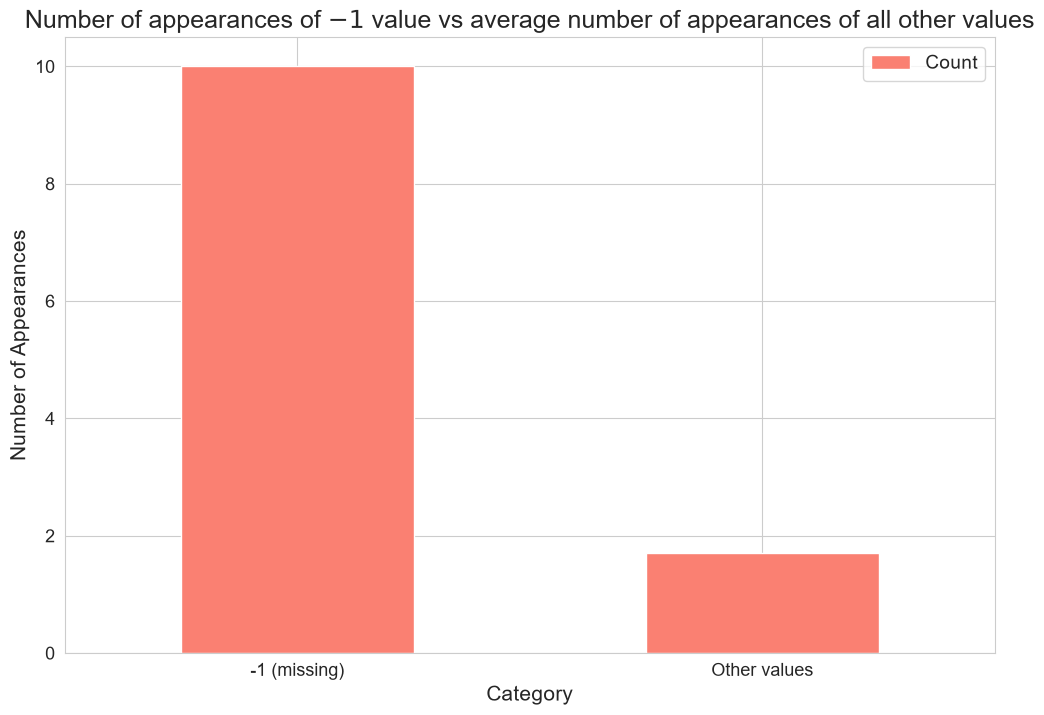

In [147]:
df["Pts_1"].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(12,8))

# Getting columns and totals required for -1 frequency comparison
pts_1_total = df[["Pts_1"]].size
pts_2_total = df[["Pts_2"]].size

pts_1_minus = df[df["Pts_1"] == -1]["Pts_1"].size
pts_2_minus = df[df["Pts_2"] == -1]["Pts_2"].size

pts_1_not_minus = df[df["Pts_1"] != -1]["Pts_1"]
pts_2_not_minus = df[df["Pts_2"] != -1]["Pts_2"]

# Mean number of appearances of not -1 points
mean_1 = pts_1_not_minus.value_counts().mean()
mean_2 = pts_2_not_minus.value_counts().mean()

# Means across both pts_1 and pts_2
total_mean = mean_1 / 2 + mean_2 / 2
minus_1_mean = pts_1_minus / 2 + pts_2_minus / 2

plot_df = pd.DataFrame({
    'Category': ['-1 (missing)', 'Other values'],
    'Count': [minus_1_mean, total_mean]
})

plot_df.plot(kind="bar", x="Category", ax=ax, color="salmon", rot=0)
ax.set_title(r"Number of appearances of $-1$ value vs average number of appearances of all other values")
ax.set_ylabel("Number of Appearances")

In [148]:
# Extract all rows where either pts column entry is -1
rows = df[(df["Pts_1"] == -1) | (df["Pts_2"] == -1)]

# Extract all rows where neither point column has a -1 entry
rows_2 = df[(df["Pts_1"] != -1) & (df["Pts_2"] != -1)]

# Get the date of the last -1 row
date = rows.iloc[-1]["Date"]

# Check that dates of all -1 rows have dates earlier than this
check = (rows["Date"] <= date).all()

# Check that all dates of non -1 rows have dates later than this
check_2 = (rows_2["Date"] > date).all()

# Check both at once
check_both = (rows["Date"] <= date).all() & (rows_2["Date"] > date).all()
print(f"The only Djokovic matches where ATP points were not stored are all matches before {date}: {check_both}")

The only Djokovic matches where ATP points were not stored are all matches before 2005-06-25: True


Hence, we have identified that all of the matches with dates earlier than $25/06/2025$ did not have the pre-match ATP points stored, and that all matches after this date do have legitemate point entries.

Next, let us analyse the odds columns. Odds must be greater than $1$, otherwise it wouldn't make sense for any bookmaker to offer this as no rational person would accept odds less than $1$, since winning would mean you lose money.

In [149]:
# Checking if odds less than 1 exist

print(f"Odds less than or equal 1 exist: {(df["Odd_1"] <= 1.0).any() & (df["Odd_2"] <= 1.0).any()}")

Odds less than or equal 1 exist: True


The above indicates that there do indeed exist rows with odd entries less than $1$. Let us work out how many of these exist.

In [150]:
# Extract number of "bad" odds rows
bad_rows = df[(df["Odd_1"] <= 1.0) | (df["Odd_2"] <= 1.0)]
bad_rows_num = bad_rows.shape[0]

# Extract total number of rows
total_size = df.shape[0]

# Calculate percentage of bad rows
pct = bad_rows_num / total_size * 100

print("Quick Odds Analysis")
print("-"*70)
print(f"The number of rows with odds less than or equal to 1 is {bad_rows_num}")
print(f"The total number of rows is {total_size}")
print(rf"The percentage of rows with odds less than or equal to 1 is {pct :.2f}%")

Quick Odds Analysis
----------------------------------------------------------------------
The number of rows with odds less than or equal to 1 is 18
The total number of rows is 1278
The percentage of rows with odds less than or equal to 1 is 1.41%


Now that we have identified that there are rows with undesirable values, we will drop these rows as they will not be useful as predictors.

In [151]:
# Drop null pts rows and bad odds rows
indices_1 = rows.index
indices_2 = bad_rows.index
df_2 = df.copy().drop(index=indices_1.union(indices_2))

# Checking the new dataframe is cleaned
print(((df_2["Pts_1"] != -1) & (df_2["Pts_2"] != -1)).all())
print(((df_2["Odd_1"] > 1) & (df_2["Odd_2"] > 1)).all())

True
True


## 4. Points and Rank wrangling

Currently, there are two points columns and two rank columns, one for each player. This is indexed by which player was given the title player $1$ and which player was given the title player $2$. Hence, as prediction columns they are ambiguous, as a model is unable to distinguish which player has which odds and rank purely from this. We will instead create new columns for Djokovic's points and rank, and columns for the opponents.

In [152]:
# Forming columns for Djokovic points/rank/odds and opponent's

dj_is_1 = df_2["Player_1"] == "Djokovic N."

df_2["dj_pts"] = np.where(dj_is_1, df_2["Pts_1"], df_2["Pts_2"])
df_2["dj_rank"] = np.where(dj_is_1, df_2["Rank_1"], df_2["Rank_2"])
df_2["dj_odds"] = np.where(dj_is_1, df_2["Odd_1"], df_2["Odd_2"])

df_2["opp_pts"] = np.where(dj_is_1, df_2["Pts_2"], df_2["Pts_1"])
df_2["opp_rank"] = np.where(dj_is_1, df_2["Rank_2"], df_2["Rank_1"])
df_2["opp_odds"] = np.where(dj_is_1, df_2["Odd_2"], df_2["Odd_1"])

Now that we have formed these new columns, the old points/rank/odds columns are unnecessary, so we will drop them. We also drop the Player 1 / Player 2 columns since we always know Djokovic is playing, and knowing the name of the opponent is not beneficial. Many of our models will require one-hot encoding for categorical data, as we cannot just give them ordered integer labels since this invents an order of magnitude for the data when there isn't one, and many models such as logistic regression depend on the magnitude of column entries. If we one-hot encoded the player columns, we would have a huge number of additional columns with mainly zeros, and some models may overfit this badly.

In [153]:
drop_cols = ["Player_1", "Player_2", "Pts_1", "Pts_2", "Rank_1", "Rank_2", "Odd_1", "Odd_2"]
df_3 = df_2.copy().drop(columns=drop_cols)

In [154]:
df_3.columns

Index(['Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of',
       'Winner', 'Score', 'dj_pts', 'dj_rank', 'dj_odds', 'opp_pts',
       'opp_rank', 'opp_odds'],
      dtype='str')

## 5. Tournament Analysis and Wrangling

Our dataset has a column that gives the tournament of the match in each row. If there are tournaments where Djokovic only played in a couple of times, then we may encounter the same one-hot encoding overfitting issues as mentioned in the previous section. Let us briefly analyse the tournament column and decide what we need to do.

In [155]:
print(f"Number of unique tournament participations: {df_3["Tournament"].nunique()}")

Number of unique tournament participations: 56


In [156]:
df_3["Tournament"].value_counts()

Tournament
Wimbledon                                     115
French Open                                   106
Australian Open                               103
US Open                                        99
Internazionali BNL d'Italia                    79
Masters Cup                                    65
Monte Carlo Masters                            54
Western & Southern Financial Group Masters     53
BNP Paribas Open                               52
Dubai Tennis Championships                     51
BNP Paribas Masters                            51
Shanghai Masters                               50
Sony Ericsson Open                             49
Rogers Masters                                 43
China Open                                     29
Mutua Madrid Open                              22
Qatar Exxon Mobil Open                         18
Serbia Open                                    15
Pacific Life Open                              13
ABN AMRO World Tennis Tournament       

We will drop the tournament column. This is for a number of reasons.

- There are some tournaments where Djokovic didn't often play. Using one-hot-encoding for these columns may lead to models overfitting to correctly predict these columns.
- The tournament column is redundant with the Location, Surface, Series and Court columns, since these columns almost always provide enough information to reconstruct the tournament column.
- One-hot-encoding may lead to situations with perfect separation. If Djokovic wins a tournament, then the labels signifying which tournament it is will lead to a perfect predictor of Djokovic winning. hence, various models will grow these coefficients very large if they are not regularised.


In [157]:
df_4 = df_3.copy().drop(columns="Tournament")

In [158]:
df_4.columns

Index(['Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner',
       'Score', 'dj_pts', 'dj_rank', 'dj_odds', 'opp_pts', 'opp_rank',
       'opp_odds'],
      dtype='str')

## 6. Win Wrangling

Currently, we have a column giving the name of the winner as a string. This is useful when we are not considering just the matches of one player. However, since we are only considering Djokovic's matches, we will change this to a binary $0$/$1$ column for Djokovic winning/losing. This encodes exactly the same information but makes it more accessible as target variable for classification tasks.

In [159]:
df_4['dj_win'] = np.where(df_4["Winner"] == "Djokovic N.", 1, 0)

In [160]:
df_4.columns

Index(['Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner',
       'Score', 'dj_pts', 'dj_rank', 'dj_odds', 'opp_pts', 'opp_rank',
       'opp_odds', 'dj_win'],
      dtype='str')

In [161]:
print(df_4['dj_win'].isin([0, 1]).all())

True


In [162]:
df_5 = df_4.copy().drop(columns="Winner")

## 7. Date Wrangling

Using raw date date gives overly complex information of the exact date of the matches that is not informative. Knowing the exact day in the month of the match is unnecessary. Knowing the month can be useful, but has redundancy with the surface column since the surfaces are arranged temporally. Knowing the year / Djokovic's age does encode some important information though, since for obvious reasons a player's age will affect the probability of the player winning the match. We will drop the day and month information, and form an age column.

In [163]:
df_5["age"] = pd.DatetimeIndex(df_5["Date"]).year - 1987

Using a raw age column indicates an assumption that there is a linear relationship between the age and log-odds of winning the match. However, in athlete's careers we often have an improvement until a peak is reached, followed by a decline. This is a nonlinear relationship that is clearly not one-directional, so we must do some further analysis to see how to alleviate this.

In [164]:
age_data = df_5.groupby(["age"])["dj_win"].agg(["mean", "size"])

print("Win percentages per age")
print("-" * 24)
(age_data).round(2)

Win percentages per age
------------------------


,mean,size
age,,
18,0.50,10
19,0.69,48
20,0.78,83
21,0.79,68
22,0.82,87
23,0.76,70
24,0.94,67
25,0.87,75
26,0.88,73


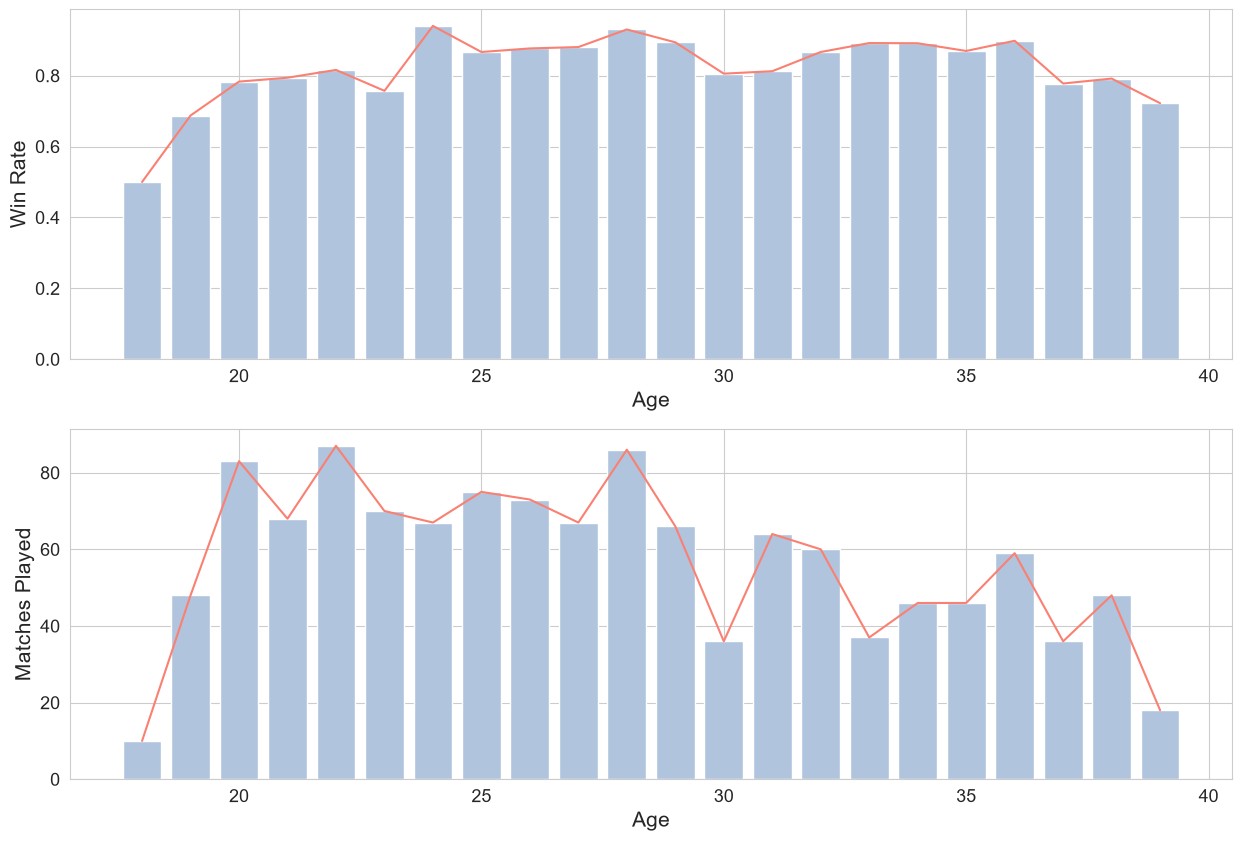

In [165]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

ax[0].bar(age_data.index, age_data["mean"], color="lightsteelblue")
ax[0].plot(age_data.index, age_data["mean"], color="salmon")
ax[0].set_ylabel("Win Rate")
ax[0].set_xlabel("Age")

ax[1].bar(age_data.index, age_data["size"], color="lightsteelblue")
ax[1].plot(age_data.index, age_data["size"], color="salmon")
ax[1].set_ylabel("Matches Played")
ax[1].set_xlabel("Age")

plt.show()

In [166]:
df_5.columns

Index(['Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Score',
       'dj_pts', 'dj_rank', 'dj_odds', 'opp_pts', 'opp_rank', 'opp_odds',
       'dj_win', 'age'],
      dtype='str')

## 8. Outdoor/Indoor, 3/5 Set Encoding

Currently, the 'Court' and 'Best of' columns gives Outdoor/Indoor labels for the setting of the court for the match. We will change this to a binary $0$/$1$ label, which encodes the exact same information and makes it easier for models to understand.

In [175]:
is_outdoor = df_5["Court"] == "Outdoor"
is_five = df_5["Best of"] == 5

df_5["is_outdoor"] = is_outdoor.astype(int)
df_5["is_five_sets"] = is_five.astype(int)

In [176]:
df_5['is_outdoor'].unique()

array([1, 0])

In [177]:
df_5["is_five_sets"].unique()

array([0, 1])

Now we drop the existing "Court" and "Best of" columns since they has been made redundant.

In [179]:
df_6 = df_5.copy().drop(columns=["Court", "Best of"])

In [180]:
df_6

,Date,Series,Surface,Round,Score,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets
10,2005-07-26,International,Clay,1st Round,6-3 6-4,417,97,1.36,259,163,2.87,1,18,1,0
11,2005-07-27,International,Clay,2nd Round,6-4 6-2,417,97,5.00,1170,28,1.14,0,18,1,0
12,2005-08-15,Masters,Hard,1st Round,6-3 6-7 4-6,440,97,3.50,1385,18,1.28,0,18,1,0
13,2005-08-30,Grand Slam,Hard,1st Round,7-5 4-6 7-5 0-6 7-5,431,97,2.50,825,43,1.50,1,18,1,1
14,2005-09-02,Grand Slam,Hard,2nd Round,6-3 5-7 7-6 6-3,431,97,3.50,1230,24,1.28,1,18,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,2026-07-01,Grand Slam,Grass,2nd Round,6-3 6-4 6-2,3760,8,1.17,700,87,5.00,1,39,1,1
1274,2026-07-03,Grand Slam,Grass,3rd Round,5-7 4-6 6-1 6-7,3760,8,1.13,1683,28,6.00,1,39,1,1
1275,2026-07-05,Grand Slam,Grass,4th Round,6-7 3-6 6-3 3-6,3760,8,1.17,458,132,5.00,1,39,1,1
1276,2026-07-07,Grand Slam,Grass,Quarterfinals,6-7 6-3 3-6 7-6 6-7,3760,8,1.57,4390,4,2.38,1,39,1,1


## 8. Moving Average

We now create a simple $5$-match moving average column. For the first $5$ rows, we use whatever number of matches is available to give an average.

In [170]:
five_sma_col = pd.Series(np.nan, index=df_6.index)

for i in range(five_sma_col.size):
    if i <= 5:
        five_sma_col.iloc[i] = df_6.iloc[:i]['dj_win'].mean()
    else:
        five_sma_col.iloc[i] = df_6.iloc[i-6:i-1]['dj_win'].mean()

df_6["5SMA"] = five_sma_col

In [171]:
df_6.head(5)["5SMA"]

10         NaN
11    1.000000
12    0.500000
13    0.333333
14    0.500000
Name: 5SMA, dtype: float64

Since the very first row/match does not have any previous matches to calculate this moving average from, it will have an NaN entry. Since this can break some models, and we already have thousands of datapoints to learn from, we will just drop this column

In [172]:
df_7 = df_6.iloc[1:]

In [173]:
df_7.head()

,Date,Series,Surface,Round,Best of,Score,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,5SMA
11,2005-07-27,International,Clay,2nd Round,3,6-4 6-2,417,97,5.00,1170,28,1.14,0,18,1,1.000000
12,2005-08-15,Masters,Hard,1st Round,3,6-3 6-7 4-6,440,97,3.50,1385,18,1.28,0,18,1,0.500000
13,2005-08-30,Grand Slam,Hard,1st Round,5,7-5 4-6 7-5 0-6 7-5,431,97,2.50,825,43,1.50,1,18,1,0.333333
14,2005-09-02,Grand Slam,Hard,2nd Round,5,6-3 5-7 7-6 6-3,431,97,3.50,1230,24,1.28,1,18,1,0.500000
15,2005-09-04,Grand Slam,Hard,3rd Round,5,1-6 6-4 7-6 4-6 4-6,431,97,2.75,770,48,1.39,0,18,1,0.600000


## 4. Win Distribution

Let us now analyse the distribution of our target variable: whether Djokovic was the winner of the match or not.

In [174]:
# Calculate number of wins, losses and win percentage
num_win = df[df["Djokovic Win"] == 1].shape[0]
num_loss = df[df["Djokovic Win"] == 0].shape[0]
win_pct = num_win / (num_loss + num_win) * 100

# Quick analysis print
print("Quick Win Analysis")
print("-"*50)
print(f"Total number of matches: {df.shape[0]}")
print(f"Number of wins: {num_win}")
print(f"Number of losses: {num_loss}")
print(f"Win percentage: {win_pct:.2f}%")

# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(20,10))

df_outcomes = pd.DataFrame({"Count": [num_win, num_loss]}, index=["Wins", "Losses"])

df_outcomes.plot(kind="bar", ax=ax[0], rot=0, y="Count", legend=False, color=["tab:blue", "tab:orange"])
df_outcomes.plot(kind="pie", ax=ax[1], y="Count")

ax[1].set_ylabel("")
fig.suptitle("Djokovic Match Outcomes", fontsize=20)
plt.tight_layout()
plt.show()

KeyError: 'Djokovic Win'

## 5. Numeric Feature Distributions

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tournament    1278 non-null   str    
 1   Date          1278 non-null   str    
 2   Series        1278 non-null   str    
 3   Court         1278 non-null   str    
 4   Surface       1278 non-null   str    
 5   Round         1278 non-null   str    
 6   Best of       1278 non-null   int64  
 7   Player_1      1278 non-null   str    
 8   Player_2      1278 non-null   str    
 9   Winner        1278 non-null   str    
 10  Rank_1        1278 non-null   int64  
 11  Rank_2        1278 non-null   int64  
 12  Pts_1         1278 non-null   int64  
 13  Pts_2         1278 non-null   int64  
 14  Odd_1         1278 non-null   float64
 15  Odd_2         1278 non-null   float64
 16  Score         1278 non-null   str    
 17  Djokovic Win  1278 non-null   int64  
dtypes: float64(2), int64(6), str(10)
memory

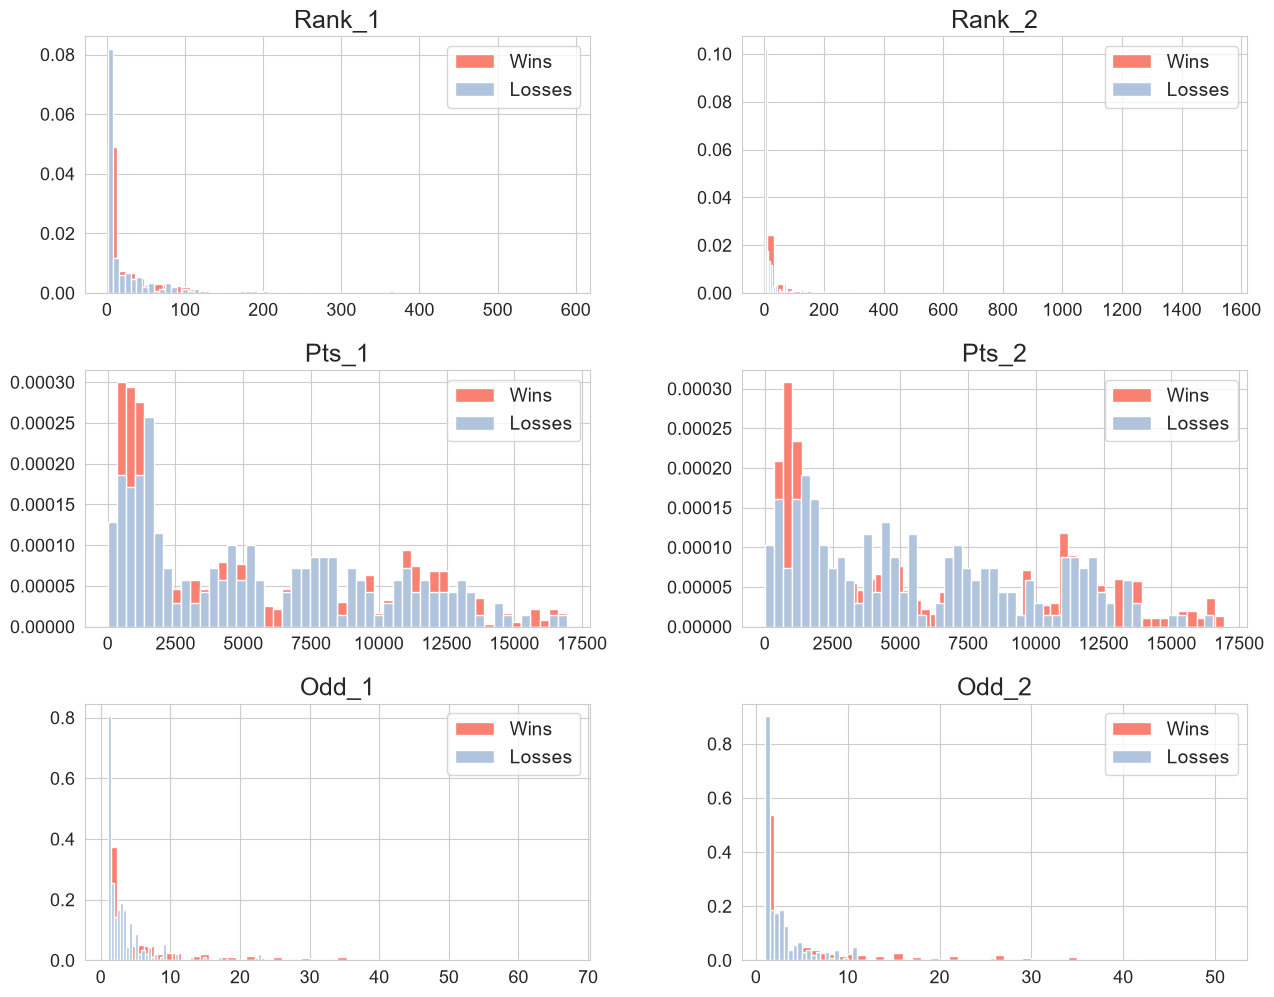

In [ ]:
df_wins = df[df["Djokovic Win"] == 1]
df_losses = df[df["Djokovic Win"] != 1]

# Get numeric columns
columns = ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']



fig, ax = plt.subplots(3, 2, figsize = (15, 12))
ax = ax.flat

for i in range(6):
    df_wins.hist(column=columns[i], ax=ax[i], bins=50, color="Salmon", label="Wins",
                  density=True)
    df_losses.hist(column=columns[i], ax=ax[i], bins=50, color="lightsteelblue",
                    label="Losses", density=True)
    ax[i].legend()
    ax[i].set_title(df[columns].columns[i])

In [ ]:
df.columns

Index(['Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of',
       'Player_1', 'Player_2', 'Winner', 'Rank_1', 'Rank_2', 'Pts_1', 'Pts_2',
       'Odd_1', 'Odd_2', 'Score', 'Djokovic Win'],
      dtype='str')